In [2]:
%pip install numpy matplotlib seaborn tensorflow

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist

from tensorflow.math import confusion_matrix

tf.random.set_seed(3)

In [8]:
(X_train, Y_train), (X_test,Y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
X_train.shape
#(60000, 28, 28)

Y_train.shape
#(60000,)

X_test.shape
#(10000, 28, 28)

Y_test.shape
#(10000,)

(10000,)

In [10]:
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)
X_test shape: (10000, 28, 28)
Y_test shape: (10000,)


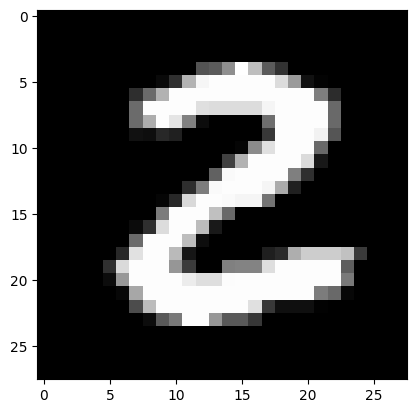

Actual label: 2


In [11]:
#Display one image from the traning dataset
plt.imshow(X_train[25], cmap='gray')
plt.show()

#Display the correct label
print("Actual label:", Y_train[25])

In [12]:
print("Image shape:", X_train[25].shape)
print("Pixel values:")
print(X_train[25])

Image shape: (28, 28)
Pixel values:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  83  91 143 255 190  91
   50   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   9  49 180 246 253 253 253 253 253
  220 154  17   3   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  46 107 178 253 253 253 253 253 253 253 253
  253 253 253 126  45   0   0   0   0   0]
 [  0   0   0   0   0   0   0 107 253 253 253 253 223 220 220 220 220 245
  253 253 253 253 106   0   0   0   0   0]
 [  0   0   0   0   0   0   

those num are the pixel intensities

In [13]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [14]:
#Normalize pixel values from 0-255 to 0-1
X_train=X_train/255.0
X_test=X_test/255.0

In [15]:
print("Minimum after normalization:", X_train.min())
print("Maximum after normalization:", X_train.max())

Minimum after normalization: 0.0
Maximum after normalization: 1.0


In [16]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,310 (165.27 KB)

 Trainable params: 42,310 (165.27 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Adam controls how the model updates its internal weights while learning.

Loss tells us how wrong the model's predictions are.

This tells Keras to report accuracy while training/evaluating.

In [20]:
history = model.fit(
    X_train,
    Y_train,
    epochs=10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9148 - loss: 0.2983
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9595 - loss: 0.1363
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9692 - loss: 0.1016
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9754 - loss: 0.0810
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9794 - loss: 0.0663
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9825 - loss: 0.0560
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9850 - loss: 0.0476
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9869 - loss: 0.0408
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9883 - loss: 0.0353
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9891 - loss: 0.0310


In [21]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9625 - loss: 0.1440
Test Loss: 0.14401549100875854
Test Accuracy: 0.9624999761581421


In [22]:
# Make predictions for all test images
predictions = model.predict(X_test)

print("Prediction shape:", predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Prediction shape: (10000, 10)


In [23]:
# Select one test image
index = 25

# Get the model's output for that image
prediction = predictions[index]

# Find the index with the highest value
predicted_label = np.argmax(prediction)

print("Predicted digit:", predicted_label)
print("Actual digit:", Y_test[index])

Predicted digit: 0
Actual digit: 0


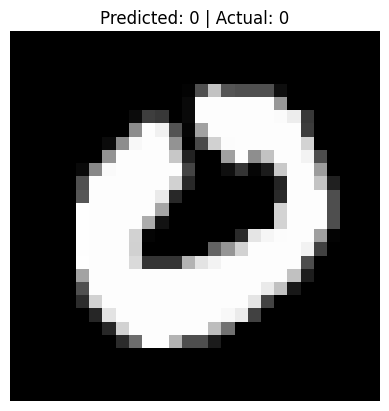

In [24]:
plt.imshow(X_test[index], cmap='gray')
plt.title(
    f"Predicted: {predicted_label} | Actual: {Y_test[index]}"
)
plt.axis('off')
plt.show()

In [25]:
# Convert model outputs into predicted digit labels
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels shape:", predicted_labels.shape)

Predicted labels shape: (10000,)


In [26]:
# Create confusion matrix
cm = confusion_matrix(Y_test, predicted_labels)

print(cm)

tf.Tensor(
[[ 944    0    5    1    5    2   12    0    2    9]
 [   0 1099    2    6    3    1    8    2   13    1]
 [   2    0  968   34    3    1    2    7   15    0]
 [   0    0    1  994    0    1    1    7    2    4]
 [   0    0    3    1  970    0    4    2    1    1]
 [   1    0    0   22    2  851    9    2    2    3]
 [   4    2    1    2    6    9  934    0    0    0]
 [   0    0    7   10    5    0    0  988    5   13]
 [   5    0    3   14    8    6    2    3  927    6]
 [   0    1    0    6   36    5    1    4    6  950]], shape=(10, 10), dtype=int32)


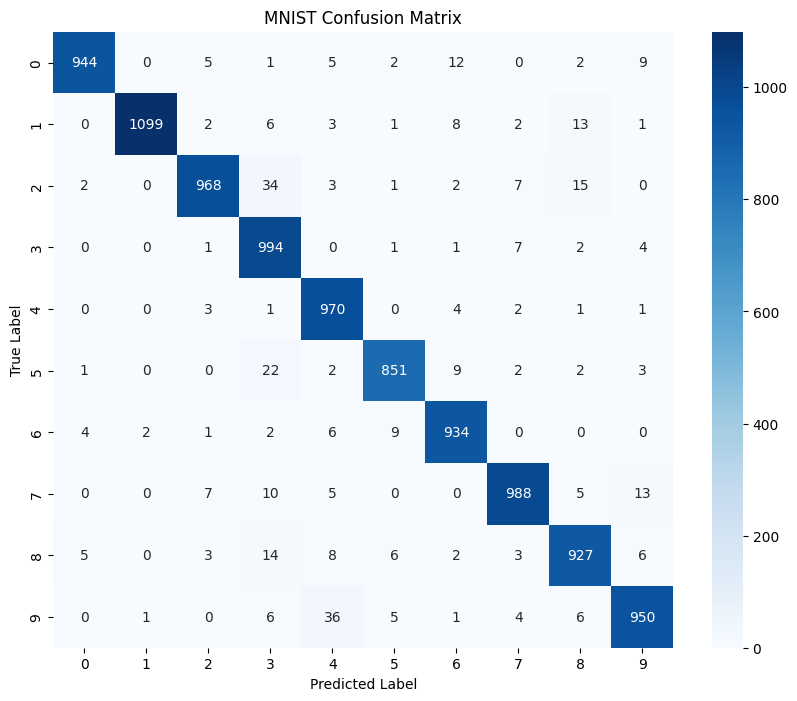

In [27]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")

plt.show()

In [29]:
#history = model.fit(...)

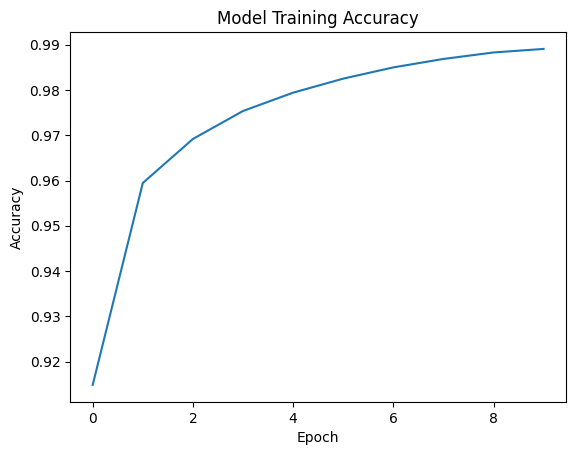

In [30]:
plt.plot(history.history['accuracy'])
plt.title('Model Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

             TRAINING
                ↓
       ┌─────────────────┐
       │ Neural Network  │
       └─────────────────┘
          ↓           ↓
     Accuracy ↑    Loss ↓
          ↓           ↓
          └─────┬─────┘
                ↓
          Model learns 🧠

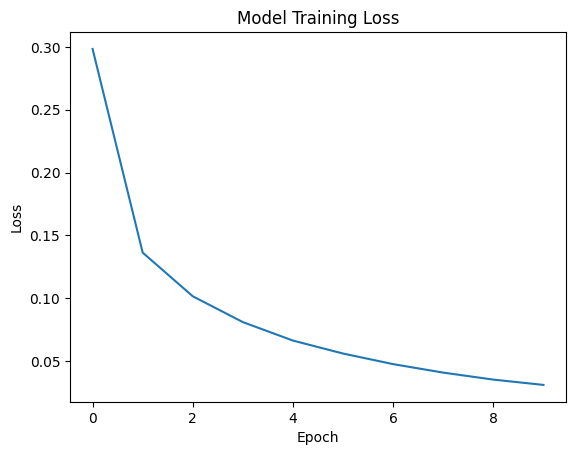

In [31]:
plt.plot(history.history['loss'])
plt.title('Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

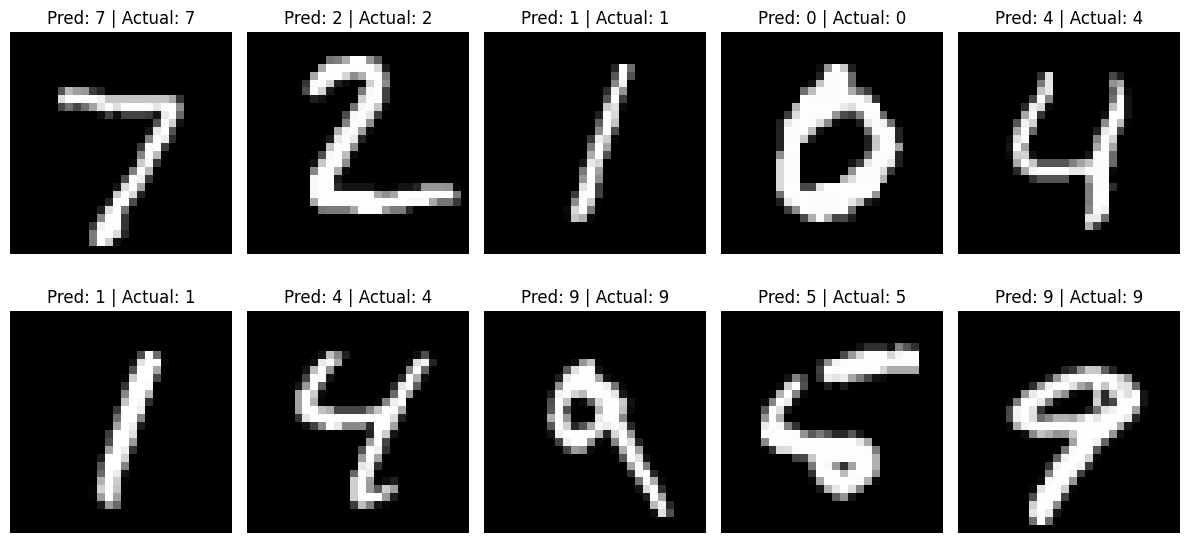

In [32]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')

    predicted = np.argmax(predictions[i])
    actual = Y_test[i]

    plt.title(f"Pred: {predicted} | Actual: {actual}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [33]:
# Find incorrectly predicted images
wrong_indices = np.where(predicted_labels != Y_test)[0]

print("Total wrong predictions:", len(wrong_indices))
print("Total test images:", len(Y_test))

Total wrong predictions: 375
Total test images: 10000


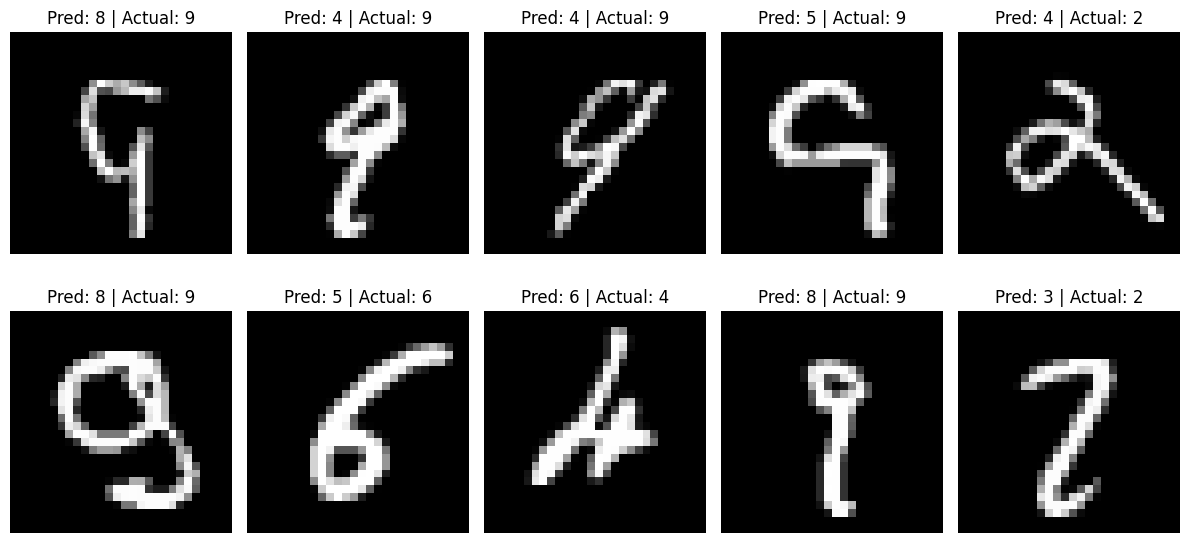

In [34]:
plt.figure(figsize=(12, 6))

for i in range(10):
    index = wrong_indices[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[index], cmap='gray')

    predicted = predicted_labels[index]
    actual = Y_test[index]

    plt.title(f"Pred: {predicted} | Actual: {actual}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [35]:
# Calculate error rate
error_rate = len(wrong_indices) / len(Y_test)

print("Correct predictions:", len(Y_test) - len(wrong_indices))
print("Wrong predictions:", len(wrong_indices))
print("Error rate:", error_rate)
print("Accuracy:", 1 - error_rate)

Correct predictions: 9625
Wrong predictions: 375
Error rate: 0.0375
Accuracy: 0.9625


In [36]:
# Save the trained model
model.save("mnist_digit_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


In [37]:
# Load the saved model
loaded_model = keras.models.load_model("mnist_digit_classifier.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [38]:
# Test the loaded model
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

print("Loaded model accuracy:", loaded_test_accuracy)

Loaded model accuracy: 0.9624999761581421
